In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
G = np.r_[1, 2]
dobs = 2

In [3]:
def phid(m): 
    residual = G @ m - dobs
    return residual ** 2

In [4]:
n_model_trials = 500 
m1_values = np.linspace(-5, 5, n_model_trials) 
m2_values = np.linspace(-5, 5, n_model_trials) 

In [8]:
phid_grid = np.zeros((n_model_trials, n_model_trials))

for i, m1 in enumerate(m1_values): 
    for j, m2 in enumerate(m2_values): 
        phid_grid[i, j] = phid(np.r_[m1, m2])

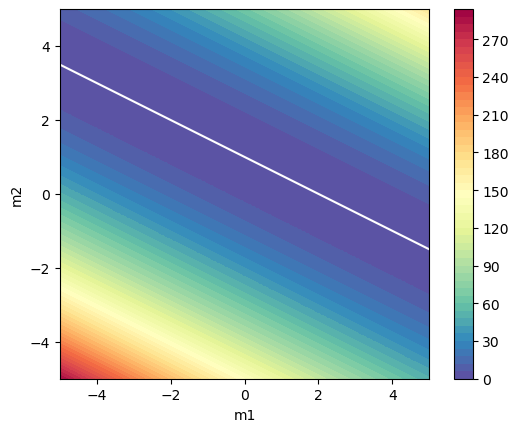

In [13]:
fig, ax = plt.subplots(1, 1) 

plt.colorbar(
    ax.contourf(m1_values, m2_values, phid_grid.T, 50, cmap="Spectral_r")
)
ax.set_xlabel("m1")
ax.set_ylabel("m2")

ax.plot(m1_values, 0.5 * (2-m1_values), "w")

ax.set_aspect(1)

In [14]:
def phim(m): 
    return m.T @ m   # same as np.sum(m**2) 

In [15]:
phim_grid = np.zeros((n_model_trials, n_model_trials))

for i, m1 in enumerate(m1_values): 
    for j, m2 in enumerate(m2_values): 
        phim_grid[i, j] = phim(np.r_[m1, m2])

In [37]:
beta = 0.5

phi_grid = phid_grid + beta * phim_grid 

phim_min = np.where(phim_grid == np.min(phim_grid))
phi_min = np.where(phi_grid == np.min(phi_grid))

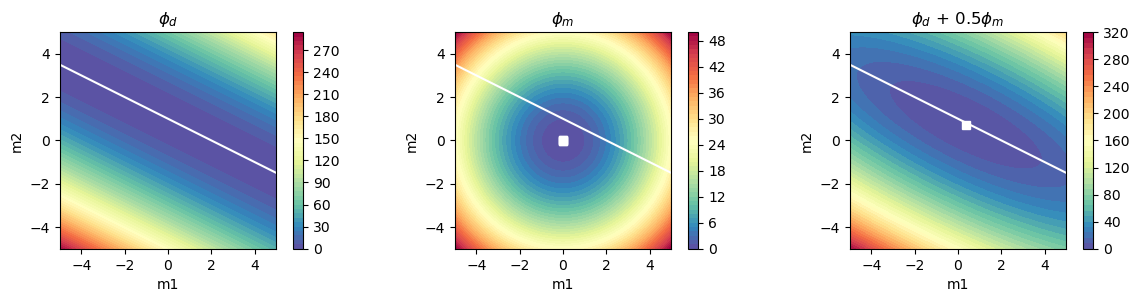

In [38]:
fig, ax = plt.subplots(1, 3, figsize=(12, 3)) 

# phid 
plt.colorbar(
    ax[0].contourf(m1_values, m2_values, phid_grid.T, 50, cmap="Spectral_r")
)
ax[0].set_title("$\\phi_d$")

# phim
plt.colorbar(
    ax[1].contourf(m1_values, m2_values, phim_grid.T, 50, cmap="Spectral_r")
)
ax[1].plot(m1_values[phim_min[0]], m2_values[phim_min[1]], "ws")
ax[1].set_title("$\\phi_m$")

# phi
plt.colorbar(
    ax[2].contourf(m1_values, m2_values, phi_grid.T, 50, cmap="Spectral_r")
)
ax[2].plot(m1_values[phi_min[0]], m2_values[phi_min[1]], "ws")
ax[2].set_title(f"$\\phi_d$ + {beta}$\\phi_m$")

for a in ax: 
    a.set_xlabel("m1")
    a.set_ylabel("m2")
    a.plot(m1_values, 0.5 * (2-m1_values), "w")
    a.set_aspect(1)

plt.tight_layout()